Percent change per 100 µA = -3.493 ± 0.670 %


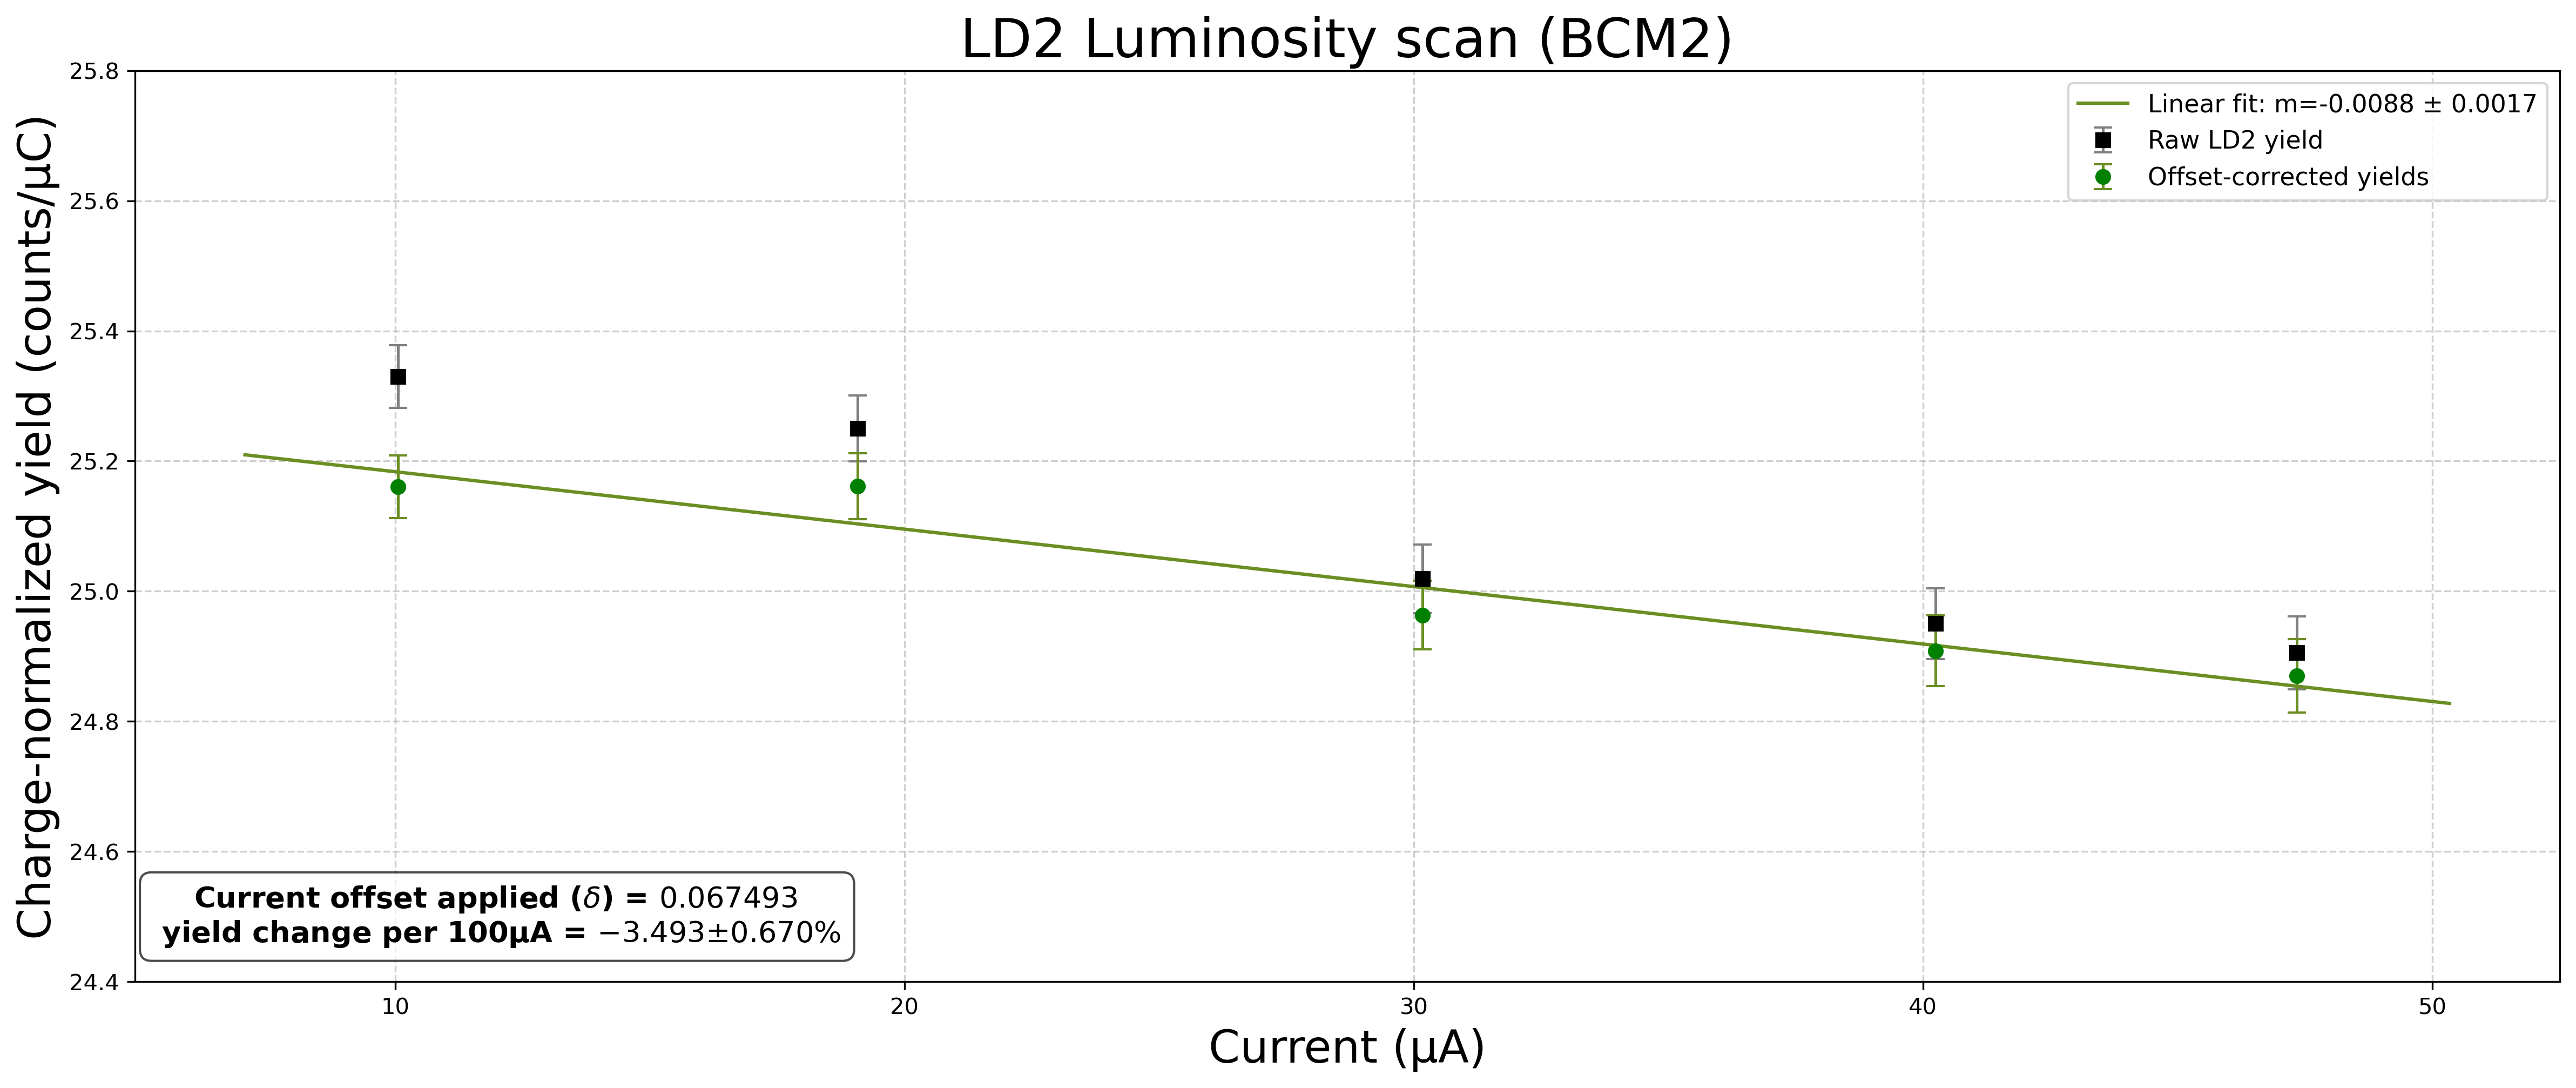

In [39]:
import numpy as np
from scipy.optimize import curve_fit, minimize_scalar, brentq, minimize
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("LD2_luminosity.csv", sep="|")

run_num = df["run_number"].to_numpy();
I=df["current"].to_numpy();
Q=df["charge"].to_numpy();
eff=df["efficiency"].to_numpy();
dead=df["deadtime"].to_numpy();
N=df["yield"].to_numpy();
PS4=df["PS4"].to_numpy();

norm=(PS4)/(Q*eff*dead)
Y_norm=N*norm
error=np.sqrt(N)*norm

δ = 0.067493
# Compute corrected yield with the optimized offset applied
factor = 1 + δ/I
Y_corr = Y_norm / factor
err_corr = error / factor

# Linear fit to the corrected LH2 yield

def line_model(I, m, I0):
    return m * I + I0

popt_line, pcov_line = curve_fit(line_model, I, Y_corr,
                                 sigma=err_corr, absolute_sigma=True)
m_fit, b_fit = popt_line
m_err, b_err = np.sqrt(np.diag(pcov_line))

I_fit = np.linspace(min(I)-3, max(I)+3, 300)

P100 = 1e4 * (m_fit / b_fit)  # in percent

# uncertainty propagation: R = m/b
cov = pcov_line
m_err = np.sqrt(cov[0,0])
b_err = np.sqrt(cov[1,1])
cov_mb = cov[0,1]

R = m_fit / b_fit
sigma_R = np.sqrt( (1/b_fit)**2 * m_err**2
                   + (m_fit/b_fit**2)**2 * b_err**2
                   - 2*(1/b_fit)*(m_fit/b_fit**2)*cov_mb )

P100_err = 1e4 * sigma_R

print(f"Percent change per 100 µA = {P100:.3f} ± {P100_err:.3f} %")


fig, ax = plt.subplots(figsize=(16,10), dpi=300)

# Raw LH2 yield
ax.errorbar(I, Y_norm, yerr=error, fmt='s', color='black', ecolor='gray',
            elinewidth=1.2, capsize=4, label="Raw LD2 yield")

# Offset-corrected yield
ax.errorbar(I, Y_corr, yerr=err_corr, fmt='o', color='green',
            ecolor='olivedrab', elinewidth=1.2, capsize=4, label="Offset-corrected yields")

ax.plot(I_fit, line_model(I_fit, m_fit, b_fit), color="olivedrab", linestyle='-',
        label=f"Linear fit: m={m_fit:.2} ± {m_err:.2}")


ax.text(12, 24.5, f"Current offset applied ($δ$) = $0.067493$ \n yield change per 100µA = ${P100:.3f} ± {P100_err:.3f} \% $ ",
        fontsize=13, color="black",
        fontweight="bold", ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.7))

ax.set_title("LD2 Luminosity scan (BCM2)", fontsize=24)
ax.set_xlabel("Current (µA)", fontsize=20)
ax.set_ylabel("Charge-normalized yield (counts/µC)",fontsize=20)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(frameon=True,fontsize=11)
plt.tight_layout()
plt.ylim(24.4,25.8)
plt.show()

24290|7|6.954|11184.157|0.9987|0.999337|1|283211|
24291|3|3.123|1821.887|0.9986|1.00000|1|46542|